# Step 3 — Reusing the Contraction Path on `tensornet`

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 3**

Notebook 2 solved the same 9-zone, 36-qubit problem with the XY-ring mixer on the `tensornet`
backend, spending about 82 seconds per `energy()` evaluation. Most of that time is spent finding
a good tensor-network *contraction path* -- the order in which tensors are multiplied together --
and CUDA-Q recomputes that path from scratch on every single call by default, even though our
circuit's structure (and therefore its optimal contraction path) never changes between
evaluations, only the numeric `gamma`/`beta` values do.

Two `tensornet` environment variables fix this: `CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE`
tells CUDA-Q to reuse the contraction path across repeated `observe`/`sample` calls with the same
circuit shape, and `CUDAQ_TENSORNET_NUM_HYPER_SAMPLES` controls how many candidate paths are tried
when a path *does* need to be found -- more samples cost more time up front but can find a
cheaper path to reuse. Everything else -- the problem, the kernel, the optimizer, the seed -- is
identical to notebook 2, so any speedup we see comes only from this reuse.

## Set the reuse environment variables before `import cudaq`

`CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE` and `CUDAQ_TENSORNET_NUM_HYPER_SAMPLES` are read by
the `tensornet` backend at import time, so they must be set first, before `cudaq` is imported.
Changing them later would need a full kernel restart. We then rebuild the exact same 9-zone,
4-color problem as notebook 2 (`A = 8.0`, `B = 1.0`, seed `1234`, `tensornet` fp32).

In [1]:
# cell 1 -- set tensornet contraction-path-reuse env vars, then rebuild the problem.
import os
os.environ["CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE"] = "TRUE"
os.environ["CUDAQ_TENSORNET_NUM_HYPER_SAMPLES"] = "32"

import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq

cudaq.set_target("tensornet", option="fp32")
cudaq.set_random_seed(1234)
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")
print("CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE =", os.environ["CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE"])
print("CUDAQ_TENSORNET_NUM_HYPER_SAMPLES            =", os.environ["CUDAQ_TENSORNET_NUM_HYPER_SAMPLES"])

taiwan = hp.load_map()
NODES = hp.ZONE_ORDER                # 9 zones
EDGES = taiwan["zone_edges"]
K = 4
A, B = 8.0, 1.0
N_ZONES = len(NODES)
N = N_ZONES * K                      # 9 * 4 = 36 qubits

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)

print(f"{N_ZONES} zones x {K} colors = {N} qubits")
print(f"spin Hamiltonian: {len(terms['z'])} Z terms + {len(terms['zz'])} ZZ terms, "
      f"constant offset {offset}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3
CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE = TRUE
CUDAQ_TENSORNET_NUM_HYPER_SAMPLES            = 32
9 zones x 4 colors = 36 qubits
spin Hamiltonian: 36 Z terms + 110 ZZ terms, constant offset 158.0


## The same `xy_kernel` as notebook 2

The kernel -- per-zone W-state preparation, the cost layer, and the XY ring mixer -- is copied
unchanged from notebook 2. This is the point: with the same circuit shape called repeatedly, the
path-reuse machinery has something consistent to reuse.

In [2]:
# cell 2 -- the xy_kernel, unchanged from notebook 2.
W_ANGLES = [2.0943951023931953, 1.9106332362490186, 1.5707963267948966]

@cudaq.kernel
def xy_kernel(n: int, n_zones: int, w_angles: list[float], zq: list[int], zc: list[float],
              zz1: list[int], zz2: list[int], zzc: list[float], gamma: float, beta: float):
    q = cudaq.qvector(n)
    for z in range(n_zones):                          # per-zone W-state preparation
        base = z * 4
        x(q[base])
        for k in range(3):
            ry.ctrl(w_angles[k], q[base + k], q[base + k + 1])
            x.ctrl(q[base + k + 1], q[base + k])
    for i in range(len(zq)):                          # cost layer: Z terms
        rz(2.0 * gamma * zc[i], q[zq[i]])
    for i in range(len(zz1)):                         # cost layer: ZZ terms
        x.ctrl(q[zz1[i]], q[zz2[i]])
        rz(2.0 * gamma * zzc[i], q[zz2[i]])
        x.ctrl(q[zz1[i]], q[zz2[i]])
    for z in range(n_zones):                          # XY ring mixer, per zone
        base = z * 4
        for k in range(4):
            qa = base + k
            qb = base + (k + 1) % 4
            h(q[qa])                                  # XX(2*beta)
            h(q[qb])
            x.ctrl(q[qa], q[qb])
            rz(2.0 * beta, q[qb])
            x.ctrl(q[qa], q[qb])
            h(q[qa])
            h(q[qb])
            rx(1.5707963267948966, q[qa])             # YY(2*beta)
            rx(1.5707963267948966, q[qb])
            x.ctrl(q[qa], q[qb])
            rz(2.0 * beta, q[qb])
            x.ctrl(q[qa], q[qb])
            rx(-1.5707963267948966, q[qa])
            rx(-1.5707963267948966, q[qb])

def energy(params):
    gamma = params[0]
    beta = params[1]
    return cudaq.observe(xy_kernel, H, N, N_ZONES, W_ANGLES, zq, zc, zz1, zz2, zzc,
                         gamma, beta).expectation() + offset

print("xy_kernel built: identical circuit shape to notebook 2, so its contraction path can be reused.")

xy_kernel built: identical circuit shape to notebook 2, so its contraction path can be reused.


## Optimize again, with path reuse turned on

We rerun the exact same optimization as notebook 2 -- `NelderMead`, `max_iterations = 5`, starting
from `gamma = 0.1, beta = 0.1` -- and time it the same way. Notebook 2's own timed run of this
optimization took 409.860 s total (81.972 s/evaluation), for the same 5 evaluations on the same
problem, on the same machine (from notebook 2's cell 3 output, notebook 2 `theta*` = (-1.470796,
3.141593) at best energy 3.500458 -- copied here only for the speedup comparison, not reused as an
input to this notebook's optimization). We then compare our elapsed time against that number.

In [3]:
# cell 3 -- optimize with Nelder-Mead, 5 evaluations total, timed; compare to notebook 2.
num_iterations = 5
START = [0.1, 0.1]

NB2_TOTAL_SECONDS = 409.860          # notebook 2, cell 3 output, this machine, 5 evaluations

optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = START

t0 = time.perf_counter()
best_energy, best_angles = optimizer.optimize(dimensions=2, function=energy)
opt_seconds = time.perf_counter() - t0
seconds_per_eval = opt_seconds / num_iterations
speedup = NB2_TOTAL_SECONDS / opt_seconds

print(f"Nelder-Mead (tensornet, path reuse): best energy {best_energy:.6f} at "
      f"gamma = {best_angles[0]:.6f}, beta = {best_angles[1]:.6f}")
print(f"{opt_seconds:.3f} s total for {num_iterations} evaluations "
      f"= {seconds_per_eval:.3f} s/evaluation")
print(f"notebook 2 (no path reuse): {NB2_TOTAL_SECONDS:.3f} s total for {num_iterations} evaluations")
print(f"speedup vs notebook 2      : {speedup:.2f}x")

Nelder-Mead (tensornet, path reuse): best energy 3.502859 at gamma = -1.470796, beta = 3.141593
160.621 s total for 5 evaluations = 32.124 s/evaluation
notebook 2 (no path reuse): 409.860 s total for 5 evaluations
speedup vs notebook 2      : 2.55x


## Sample the optimized circuit

With `best_angles` fixed, we sample `SHOTS = 2000` times -- after optimization finished, never
before -- and decode every bitstring with `helpers.summarize_samples`. The one check in this
notebook: the best sampled bitstring is a valid coloring.

In [4]:
# cell 4 -- sample SHOTS = 2000 shots at the best angles found, summarize, and check validity.
SHOTS = 2000

t0 = time.perf_counter()
shots = cudaq.sample(xy_kernel, N, N_ZONES, W_ANGLES, zq, zc, zz1, zz2, zzc,
                     best_angles[0], best_angles[1], shots_count=SHOTS)
sample_seconds = time.perf_counter() - t0
seconds_per_shot = sample_seconds / SHOTS

counts = {}
for bitstring, times_seen in shots.items():
    counts[bitstring] = times_seen

result = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid coloring.
assert result["best"] is not None and hp.is_valid(result["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid coloring")
print(f"{sample_seconds:.3f} s total for {SHOTS} shots = {seconds_per_shot:.6f} s/shot")

valid colorings among raw samples: 16 / 2,000 shots = 0.8000%  (16 distinct bitstrings)
best valid coloring: '100001000010010010000010000101000001' (sampled 1 times, energy 0.0)
   Taipei=0, Keelung=1, Taoyuan-Hsinchu-Miaoli=2, Yilan=1, Taichung-Changhua-Nantou=0, Yunlin-Chiayi=2, Tainan=3, South=1, East=3
check passed: the best sampled bitstring is a valid coloring
110.710 s total for 2000 shots = 0.055355 s/shot


## Draw the coloring, then report the speedup table

Finally, paint every county by its zone's decoded color, draw the 9-zone adjacency graph over the
map, and add the color legend, exactly as in notebook 2. We then print a table comparing notebook
2's per-evaluation cost against this notebook's, the resulting speedup and verdict, and the
optimized angles `theta*` at full precision together with the exact best energy -- both of which
notebook 4 will need.

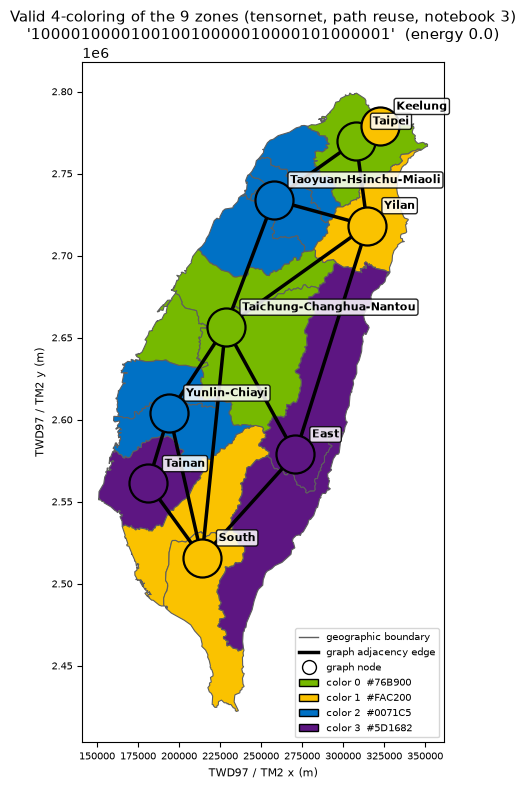

SUMMARY
------------------------------------------------------------------
problem              : 9 zones x 4 colors = 36 qubits, A = 8.0, B = 1.0
backend               : tensornet (fp32), contraction path reuse ON
------------------------------------------------------------------
                           notebook 2     notebook 3
s / evaluation                 81.972         32.124
optimize s (total)            409.860        160.621
------------------------------------------------------------------
speedup               : 2.55x
verdict               : path reuse made evaluations faster
theta* (gamma, beta)  : (-1.470796, 3.141593)
best energy (exact)   : 3.5028588799862916
time per shot         : 0.055355 s  (sampling, 2000 shots)
valid-sample rate     : 0.8000% of 2000 shots
------------------------------------------------------------------


In [5]:
# cell 5 -- draw the coloring, then report the timing table, speedup, and theta*.
best_coloring = result["assignment"]
unit_colors = {}
for name, county in taiwan["counties"].items():
    unit_colors[name] = hp.PALETTE[best_coloring[county["zone"]]]
node_colors = {}
for zone in hp.ZONE_ORDER:
    node_colors[zone] = hp.PALETTE[best_coloring[zone]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "zone"), edges=EDGES,
                      node_colors=node_colors, unit_labels=False, color_legend=True,
                      title="Valid 4-coloring of the 9 zones (tensornet, path reuse, notebook 3)\n"
                            f"'{result['best']}'  (energy {result['best_energy']:.1f})")
plt.show()

nb2_seconds_per_eval = NB2_TOTAL_SECONDS / num_iterations
verdict = "faster" if speedup > 1.0 else "no faster (or slower)"

print("SUMMARY")
print("-" * 66)
print(f"problem              : {N_ZONES} zones x {K} colors = {N} qubits, A = {A}, B = {B}")
print(f"backend               : tensornet (fp32), contraction path reuse ON")
print("-" * 66)
print(f"{'':22s} {'notebook 2':>14s} {'notebook 3':>14s}")
print(f"{'s / evaluation':22s} {nb2_seconds_per_eval:14.3f} {seconds_per_eval:14.3f}")
print(f"{'optimize s (total)':22s} {NB2_TOTAL_SECONDS:14.3f} {opt_seconds:14.3f}")
print("-" * 66)
print(f"speedup               : {speedup:.2f}x")
print(f"verdict               : path reuse made evaluations {verdict}")
print(f"theta* (gamma, beta)  : ({best_angles[0]:.6f}, {best_angles[1]:.6f})")
print(f"best energy (exact)   : {best_energy}")
print(f"time per shot         : {seconds_per_shot:.6f} s  (sampling, {SHOTS} shots)")
print(f"valid-sample rate     : {result['valid_rate']:.4%} of {SHOTS} shots")
print("-" * 66)